# Main Working File

1. Load and analyze the wafer dataset
2. Preprocess the data and perform classical SVC
3. Preprocess the data and perform Quantum SVC

In [177]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score

from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityStatevectorKernel
from qiskit_machine_learning.algorithms import QSVC
from qiskit.circuit.library import zz_feature_map

import pickle
import random


## 1. Load and analyze the WaferMap dataset

Uncomment the appropriate code below to download a local copy of the dataset from Kaggle. I have already downloaded it and the path refers to my local machine, you will need to replace with your own.

The dataset consists of 38,015 maps of semiconductor wafers, each of which is 52x52 pixels. Each image has a corresponding label, which are 8 boolean variables identifying the presence (1) or absence (0) of a macroscopic defect type.

In [166]:
#data comes from: https://www.kaggle.com/datasets/co1d7era/mixedtype-wafer-defect-datasets
#more info here: https://github.com/Junliangwangdhu/WaferMap

#import kagglehub

# Download latest version
#path = kagglehub.dataset_download("co1d7era/mixedtype-wafer-defect-datasets")

#print("Path to dataset files:", path)

#load the dataset .npz file
# YOU WILL NEED TO MODIFY THIS PATH TO POINT TO THE LOCATION OF THE .npz FILE ON YOUR SYSTEM
data = np.load("/Users/stephenreagin/.cache/kagglehub/datasets/co1d7era/mixedtype-wafer-defect-datasets/versions/4/Wafer_Map_Datasets.npz", allow_pickle=False)

#print the keys of the data dictionary
print(f"The data keys are {list(data.keys())}")

#print the shape and dtype of each array in the data dictionary
for key in data.keys():
    arr = data[key]
    print(f"{key}: shape={arr.shape}, dtype={arr.dtype}")


#arrange the data into image and label arrays
#uncomment the slicing to use only a subset of the data for faster testing
#but beware: the defects are not uniformly distributed, so slicing may result in some defect types being underrepresented or missing entirely
image_array = data['arr_0']#[:5000]
label_array = data['arr_1']#[:5000]

The data keys are ['arr_0', 'arr_1']
arr_0: shape=(38015, 52, 52), dtype=int32
arr_1: shape=(38015, 8), dtype=int32


In [172]:
print(f"There are 8 categories of defects, ordered 0 - 7. \nA typical label is {label_array[50]}")

There are 8 categories of defects, ordered 0 - 7. 
A typical label is [1 0 1 0 0 0 1 0]


Each image has shape (52, 52) and dtype int32


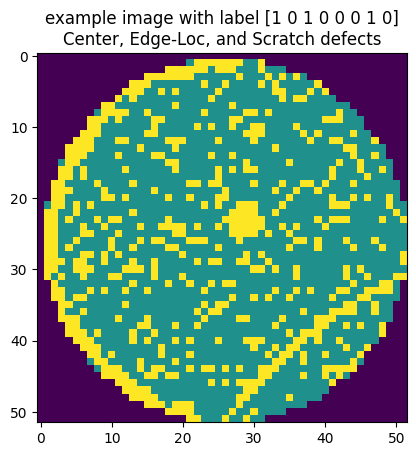

In [176]:
#each image is a 52x52 array of pixel values, and each label is an integer from 0 to 7 corresponding to the defect type
print(f"Each image has shape {image_array[0].shape} and dtype {image_array[0].dtype}")
plt.title(f"example image with label {label_array[50]}\nCenter, Edge-Loc, and Scratch defects")
plt.imshow(image_array[50]);

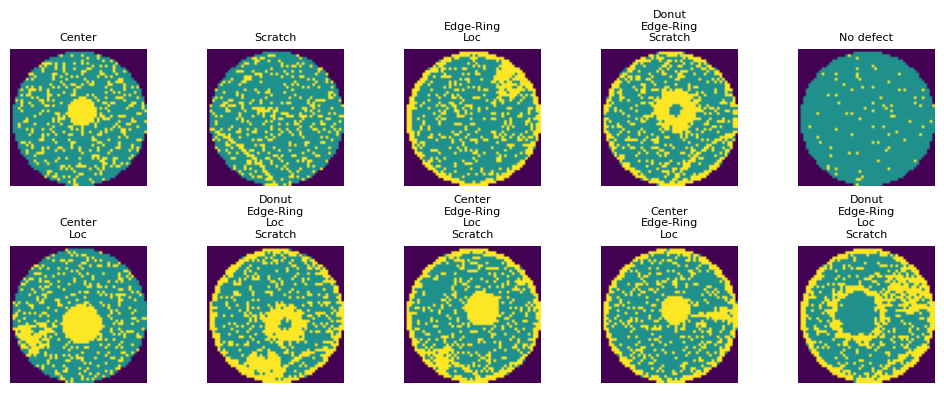

In [ ]:
# Here are some randomly-selected wafers that exhibit multiple defect types
label_names = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-Full', 'Scratch', 'Random']

indices = random.sample(range(len(image_array)), 10)  # 10 random indices

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flatten()

for i, idx in enumerate(indices):
    axes[i].imshow(image_array[idx], cmap='viridis')
    axes[i].axis('off')
    active = [label_names[j] for j, val in enumerate(label_array[idx]) if val == 1]
    axes[i].set_title('\n'.join(active) if active else 'No defect', fontsize=8)

plt.tight_layout()
plt.savefig('wafer_images.png', dpi=300)
plt.show()

### Sidequest: organizing the data for training a machine learning model

We are ultimately comparing a classical version of Support Vector Machine classification (SVC) against a quantum version of the algorithm (QSVC). However, there are two immediate issues with the data structure:
1. We need our image data to be two-dimensional, but the data array is organized along 3 dimensions:
    * 52x52 pixels per wafer (2 dimensions)
    * 38,015 wafers (another dimension)
2. Our target class needs to be a single Boolean variable (0/1), but the defect labels for each wafer are an 8x1 row vector of Booleans

To address the first problem we are we are going to flatten the image data into a single vector. That is, instead of each image being an array of 52 rows and 52 columns, we flatten them into a single ordered row of $52 \times 52 = 2704$ pixels

To address the second problem, we create 8 different target datasets, one for each defect type. Each target will be a single Boolean

In [ ]:
# Step 1: flatten the 2D images into 1D vectors
n_samples = image_array.shape[0]
X_flat = image_array.reshape(n_samples, -1)

# Extract a single defect's labels for training
target_0 = label_array[:, 0]
target_1 = label_array[:, 1]
target_2 = label_array[:, 2]
target_3 = label_array[:, 3]
target_4 = label_array[:, 4]
target_5 = label_array[:, 5]
target_6 = label_array[:, 6]
target_7 = label_array[:, 7]


## Part 2: Classical SVM

The processing steps are as follows:
1. Sample only 20% of the data to get a much smaller dataset, i.e. 7,603 total wafers (from an original 38,015)
    * Ideally we wouldn't do this, but Quantum SVC takes forever to train via simulation so we must limit the training samples at this stage
    * Therefore we must also do it for the classical SVC for an apples-to-apples comparison
2. Split into 80% training and 20% testing/validation data
    * This is just a commonly-used split
2. Perform dimensionality reduction using Principal Component Analysis (PCA) to greatly reduce the 2,704 dimensions of our flattened datasets
    * Quantum computers do not yet have 2,700+ qubits to perform operations, and simulating a 2,700 qubit system is intractible for my laptop (and all the combined computing power on Earth)
    * Therefore we will run multiple algorithms using $n=1, 2, 3,...$ up to about 30 dimensions for classical SVC

Then we train the `SVC()` classifier with standard hyperparameters, except we also include the argument `class_weight='balanced'` because several of our defects are imbalanced (lots of 0s, only a few 1s).

The training iteration steps are:
1. Loop through every target defect
    * `target_0` = 'Center', 
    * `target_1` = 'Donut', 
    * `target_2` = 'Edge-Loc', 
    * `target_3` = 'Edge-Ring', 
    * `target_4` = 'Loc', 
    * `target_5` = 'Near-Full', 
    * `target_6` = 'Scratch', 
    * `target_7` = 'Random'
2. Loop through a range of PCA dimensions
    * `n=1,2,3,...,30`
3. Train the `SVC` on each particular target defect / dimensionality combination
4. Record each of four different scoring metrics:
    * Accuracy
    * Precision
    * Recall
    * F1

Then we generate an image showing how each of these metrics changes with the number of $n$ dimensions

In [179]:
X_flat.shape

(38015, 2704)

In [ ]:
def classical_svm(y, n):
    # Split the data into training and test sets, stratifying by the target labels to maintain class balance
    #this is done twice to sample a much smaller validation set for comparison against QSVC
    X_train1, X_test1, y_train1, y_test1 = train_test_split(X_flat, y, test_size=0.2, random_state=42, stratify=y)
    X_train, X_test, y_train, y_test = train_test_split(X_test1, y_test1, test_size=0.2, random_state=42, stratify=y_test1)

    #uncomment the following line to use the full dataset rather than a 20% sampled set, but beware of overfitting and longer training times
    #X_train, X_test, y_train, y_test = train_test_split(X_flat, y, test_size=0.2, random_state=42, stratify=y)
    
    # Scale first
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test) 
    
    #reduce dimensionality with PCA
    pca = PCA(n_components=n)  # keep top n components
    X_train = pca.fit_transform(X_train)  
    X_test = pca.transform(X_test)  
    
    # Optional: check explained variance
    print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.3f}")
    
    svm_classifier = SVC(kernel='rbf', C=1, gamma='scale', class_weight='balanced')
    svm_classifier.fit(X_train, y_train)
    y_pred = svm_classifier.predict(X_test)

    #print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    #print("Accuracy:", accuracy_score(y_test, y_pred))
    #print("Recall:", recall_score(y_test, y_pred))
    #print("Precision:", precision_score(y_test, y_pred))
    #print("F1 Score:", f1_score(y_test, y_pred))

    return accuracy_score(y_test, y_pred), recall_score(y_test, y_pred), precision_score(y_test, y_pred, zero_division=0), f1_score(y_test, y_pred, zero_division=0)

In [139]:
def end_to_end_svm(target_defect, defect_label):
    print(f"\nEvaluating SVM for {defect_label} defect with varying PCA components...\n")
    accuracy_list = []
    recall_list = []
    precision_list = []
    f1_list = []

    endpoint=30
    for i in range(1,endpoint+1):
        print(f"{i} PCA components:")
        acc, recall, precision, f1 = classical_svm(target_defect,i)
        accuracy_list.append(acc)
        recall_list.append(recall)
        precision_list.append(precision)
        f1_list.append(f1)
        print("\n" + "="*50 + "\n")


    n_values = range(1, endpoint+1)
    fig, axes = plt.subplots(2, 2, figsize=(8, 6))
    fig.suptitle(f"SVM Metrics vs. PCA Components — {defect_label} Defect", fontsize=14)

    for ax, (metric_name, values) in zip(axes.flatten(), zip(
        ["Accuracy", "Recall", "Precision", "F1 Score"],
        [accuracy_list, recall_list, precision_list, f1_list]
    )):
        ax.plot(n_values, values, marker='o')
        ax.set_title(metric_name)
        ax.set_xlabel("n_components")
        ax.set_ylabel("Score")
        ax.set_ylim(0, 1)
        ax.grid(True)

    plt.tight_layout()
    plt.savefig(f'SVM_results/classical_svm_limited_{defect_label}_defect.png', dpi=300)
    plt.show()
    

    return accuracy_list, recall_list, precision_list, f1_list


Evaluating SVM for Center defect with varying PCA components...

1 PCA components:
Total variance explained: 0.058
Confusion Matrix:
 [[330 671]
 [ 53 467]]


2 PCA components:
Total variance explained: 0.097
Confusion Matrix:
 [[366 635]
 [ 29 491]]


3 PCA components:
Total variance explained: 0.124
Confusion Matrix:
 [[773 228]
 [ 94 426]]


4 PCA components:
Total variance explained: 0.142
Confusion Matrix:
 [[908  93]
 [ 32 488]]


5 PCA components:
Total variance explained: 0.153
Confusion Matrix:
 [[909  92]
 [ 31 489]]


6 PCA components:
Total variance explained: 0.164
Confusion Matrix:
 [[914  87]
 [ 31 489]]


7 PCA components:
Total variance explained: 0.174
Confusion Matrix:
 [[913  88]
 [ 28 492]]


8 PCA components:
Total variance explained: 0.184
Confusion Matrix:
 [[917  84]
 [ 31 489]]


9 PCA components:
Total variance explained: 0.191
Confusion Matrix:
 [[926  75]
 [ 30 490]]


10 PCA components:
Total variance explained: 0.199
Confusion Matrix:
 [[934  67]
 [ 33 4

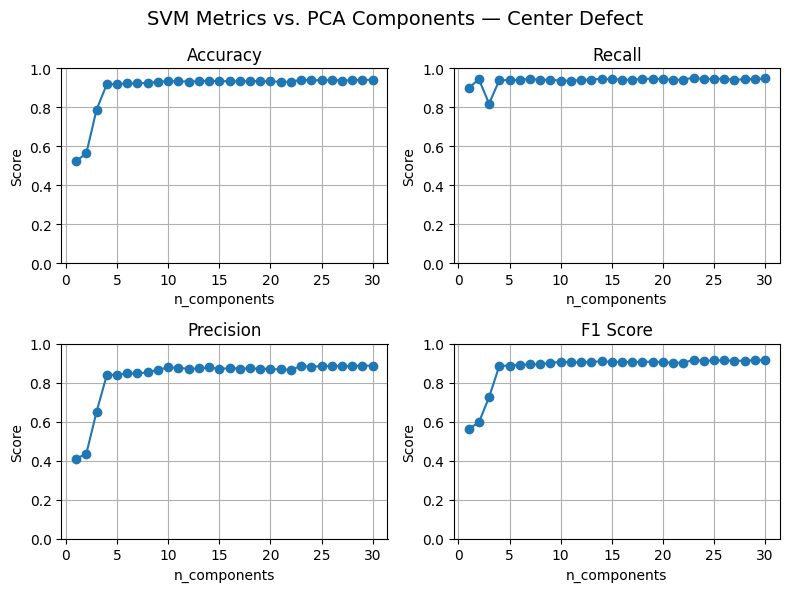


Evaluating SVM for Donut defect with varying PCA components...

1 PCA components:
Total variance explained: 0.057
Confusion Matrix:
 [[874 167]
 [ 87 393]]


2 PCA components:
Total variance explained: 0.096
Confusion Matrix:
 [[899 142]
 [ 90 390]]


3 PCA components:
Total variance explained: 0.123
Confusion Matrix:
 [[882 159]
 [ 24 456]]


4 PCA components:
Total variance explained: 0.141
Confusion Matrix:
 [[996  45]
 [ 28 452]]


5 PCA components:
Total variance explained: 0.153
Confusion Matrix:
 [[1002   39]
 [  32  448]]


6 PCA components:
Total variance explained: 0.164
Confusion Matrix:
 [[999  42]
 [ 32 448]]


7 PCA components:
Total variance explained: 0.173
Confusion Matrix:
 [[1003   38]
 [  28  452]]


8 PCA components:
Total variance explained: 0.180
Confusion Matrix:
 [[1010   31]
 [  26  454]]


9 PCA components:
Total variance explained: 0.188
Confusion Matrix:
 [[1026   15]
 [  21  459]]


10 PCA components:
Total variance explained: 0.195
Confusion Matrix:
 [[1

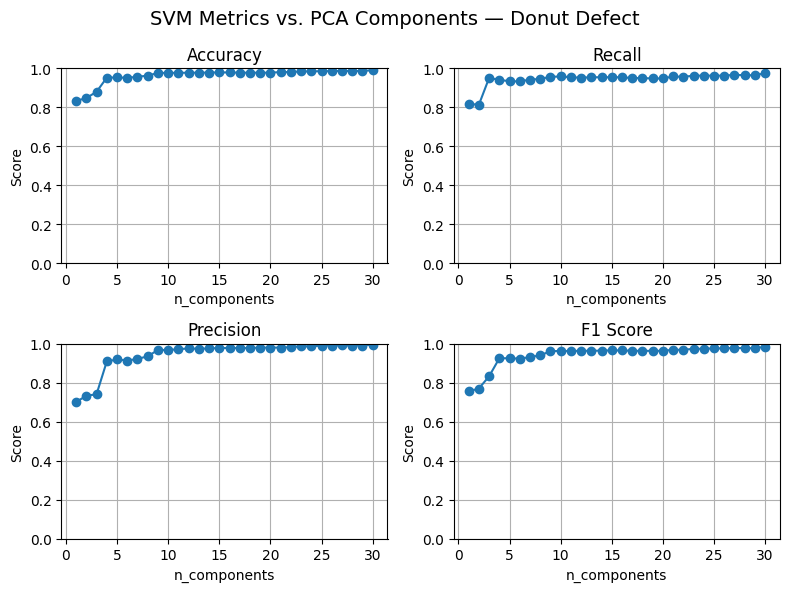


Evaluating SVM for Edge-Loc defect with varying PCA components...

1 PCA components:
Total variance explained: 0.054
Confusion Matrix:
 [[225 776]
 [ 70 450]]


2 PCA components:
Total variance explained: 0.093
Confusion Matrix:
 [[948  53]
 [ 44 476]]


3 PCA components:
Total variance explained: 0.120
Confusion Matrix:
 [[938  63]
 [ 38 482]]


4 PCA components:
Total variance explained: 0.137
Confusion Matrix:
 [[934  67]
 [ 39 481]]


5 PCA components:
Total variance explained: 0.149
Confusion Matrix:
 [[930  71]
 [ 39 481]]


6 PCA components:
Total variance explained: 0.160
Confusion Matrix:
 [[930  71]
 [ 40 480]]


7 PCA components:
Total variance explained: 0.171
Confusion Matrix:
 [[930  71]
 [ 39 481]]


8 PCA components:
Total variance explained: 0.180
Confusion Matrix:
 [[927  74]
 [ 39 481]]


9 PCA components:
Total variance explained: 0.188
Confusion Matrix:
 [[931  70]
 [ 37 483]]


10 PCA components:
Total variance explained: 0.195
Confusion Matrix:
 [[932  69]
 [ 38

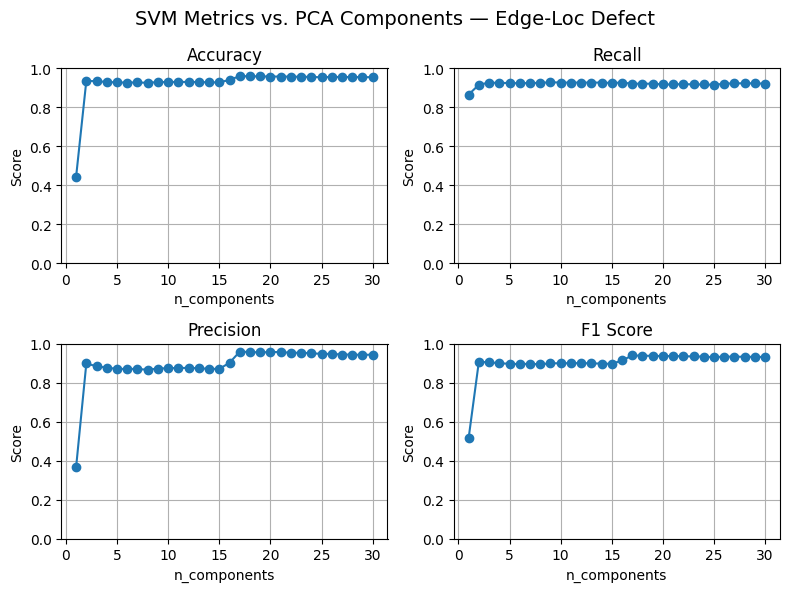


Evaluating SVM for Edge-Ring defect with varying PCA components...

1 PCA components:
Total variance explained: 0.057
Confusion Matrix:
 [[492 549]
 [ 91 389]]


2 PCA components:
Total variance explained: 0.096
Confusion Matrix:
 [[964  77]
 [  2 478]]


3 PCA components:
Total variance explained: 0.124
Confusion Matrix:
 [[962  79]
 [  1 479]]


4 PCA components:
Total variance explained: 0.142
Confusion Matrix:
 [[965  76]
 [  1 479]]


5 PCA components:
Total variance explained: 0.153
Confusion Matrix:
 [[963  78]
 [  1 479]]


6 PCA components:
Total variance explained: 0.164
Confusion Matrix:
 [[964  77]
 [  2 478]]


7 PCA components:
Total variance explained: 0.174
Confusion Matrix:
 [[964  77]
 [  2 478]]


8 PCA components:
Total variance explained: 0.181
Confusion Matrix:
 [[965  76]
 [  1 479]]


9 PCA components:
Total variance explained: 0.188
Confusion Matrix:
 [[966  75]
 [  2 478]]


10 PCA components:
Total variance explained: 0.195
Confusion Matrix:
 [[965  76]
 [  

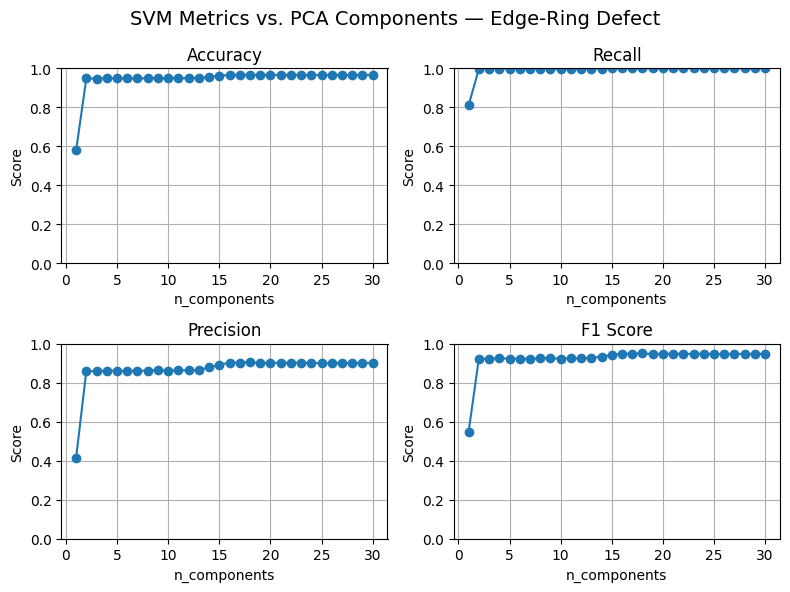


Evaluating SVM for Loc defect with varying PCA components...

1 PCA components:
Total variance explained: 0.057
Confusion Matrix:
 [[450 351]
 [125 595]]


2 PCA components:
Total variance explained: 0.097
Confusion Matrix:
 [[459 342]
 [125 595]]


3 PCA components:
Total variance explained: 0.124
Confusion Matrix:
 [[712  89]
 [133 587]]


4 PCA components:
Total variance explained: 0.142
Confusion Matrix:
 [[728  73]
 [144 576]]


5 PCA components:
Total variance explained: 0.153
Confusion Matrix:
 [[731  70]
 [149 571]]


6 PCA components:
Total variance explained: 0.164
Confusion Matrix:
 [[727  74]
 [148 572]]


7 PCA components:
Total variance explained: 0.173
Confusion Matrix:
 [[749  52]
 [140 580]]


8 PCA components:
Total variance explained: 0.181
Confusion Matrix:
 [[770  31]
 [134 586]]


9 PCA components:
Total variance explained: 0.189
Confusion Matrix:
 [[781  20]
 [119 601]]


10 PCA components:
Total variance explained: 0.195
Confusion Matrix:
 [[787  14]
 [115 605]

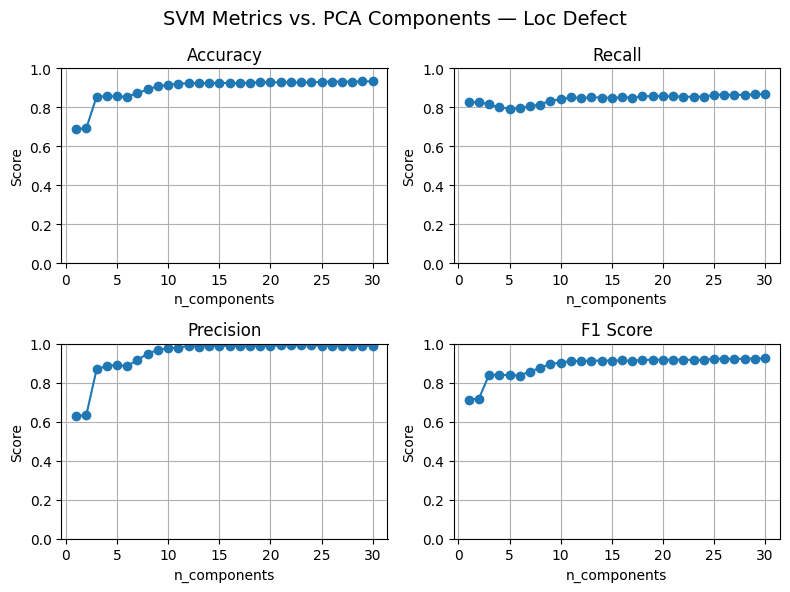


Evaluating SVM for Near-Full defect with varying PCA components...

1 PCA components:
Total variance explained: 0.055
Confusion Matrix:
 [[1500   15]
 [   0    6]]


2 PCA components:
Total variance explained: 0.094
Confusion Matrix:
 [[1507    8]
 [   0    6]]


3 PCA components:
Total variance explained: 0.122
Confusion Matrix:
 [[1515    0]
 [   0    6]]


4 PCA components:
Total variance explained: 0.140
Confusion Matrix:
 [[1515    0]
 [   0    6]]


5 PCA components:
Total variance explained: 0.151
Confusion Matrix:
 [[1515    0]
 [   0    6]]


6 PCA components:
Total variance explained: 0.162
Confusion Matrix:
 [[1515    0]
 [   0    6]]


7 PCA components:
Total variance explained: 0.171
Confusion Matrix:
 [[1515    0]
 [   0    6]]


8 PCA components:
Total variance explained: 0.179
Confusion Matrix:
 [[1515    0]
 [   0    6]]


9 PCA components:
Total variance explained: 0.187
Confusion Matrix:
 [[1515    0]
 [   0    6]]


10 PCA components:
Total variance explained: 0.19

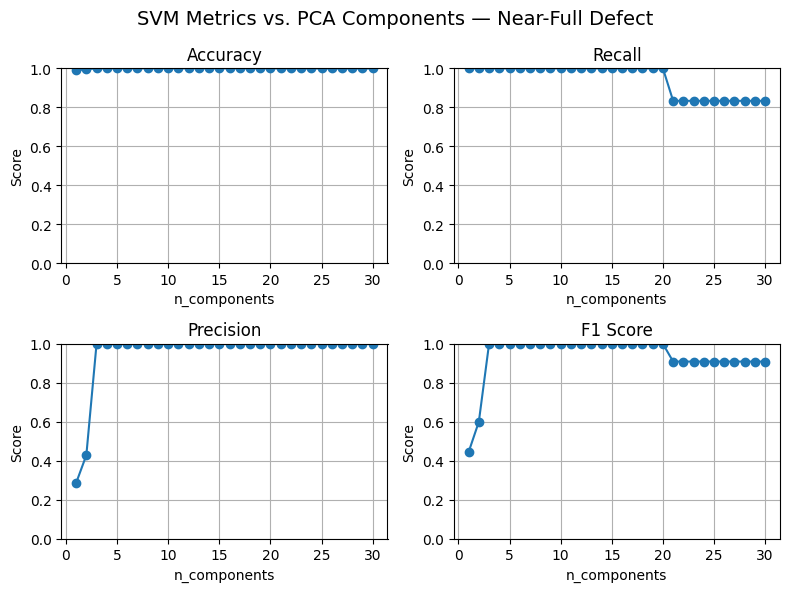


Evaluating SVM for Scratch defect with varying PCA components...

1 PCA components:
Total variance explained: 0.058
Confusion Matrix:
 [[231 530]
 [119 641]]


2 PCA components:
Total variance explained: 0.097
Confusion Matrix:
 [[218 543]
 [ 92 668]]


3 PCA components:
Total variance explained: 0.125
Confusion Matrix:
 [[452 309]
 [242 518]]


4 PCA components:
Total variance explained: 0.143
Confusion Matrix:
 [[459 302]
 [247 513]]


5 PCA components:
Total variance explained: 0.155
Confusion Matrix:
 [[479 282]
 [219 541]]


6 PCA components:
Total variance explained: 0.166
Confusion Matrix:
 [[485 276]
 [124 636]]


7 PCA components:
Total variance explained: 0.175
Confusion Matrix:
 [[476 285]
 [113 647]]


8 PCA components:
Total variance explained: 0.183
Confusion Matrix:
 [[507 254]
 [ 98 662]]


9 PCA components:
Total variance explained: 0.190
Confusion Matrix:
 [[533 228]
 [ 68 692]]


10 PCA components:
Total variance explained: 0.197
Confusion Matrix:
 [[541 220]
 [ 71 

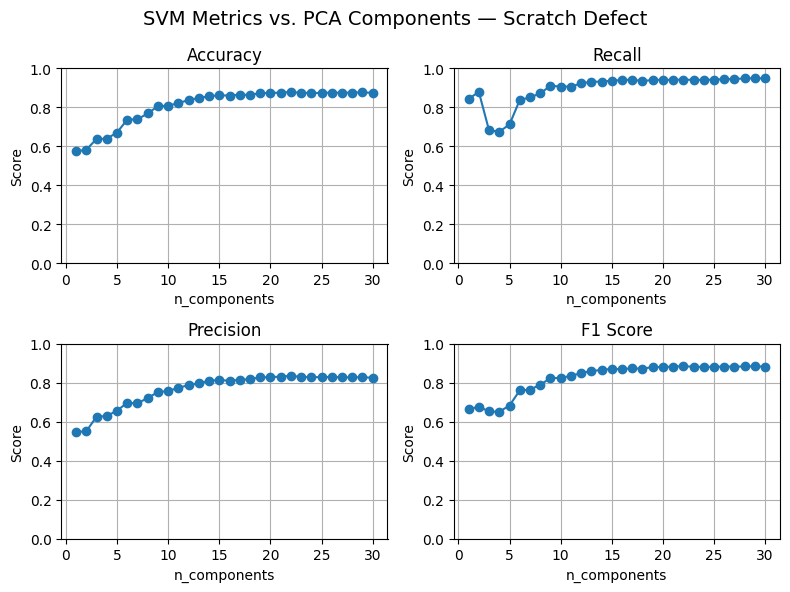


Evaluating SVM for Random defect with varying PCA components...

1 PCA components:
Total variance explained: 0.056
Confusion Matrix:
 [[1481    5]
 [   0   35]]


2 PCA components:
Total variance explained: 0.095
Confusion Matrix:
 [[1485    1]
 [   1   34]]


3 PCA components:
Total variance explained: 0.123
Confusion Matrix:
 [[1485    1]
 [   0   35]]


4 PCA components:
Total variance explained: 0.141
Confusion Matrix:
 [[1485    1]
 [   0   35]]


5 PCA components:
Total variance explained: 0.152
Confusion Matrix:
 [[1485    1]
 [   0   35]]


6 PCA components:
Total variance explained: 0.163
Confusion Matrix:
 [[1485    1]
 [   0   35]]


7 PCA components:
Total variance explained: 0.173
Confusion Matrix:
 [[1485    1]
 [   0   35]]


8 PCA components:
Total variance explained: 0.181
Confusion Matrix:
 [[1485    1]
 [   0   35]]


9 PCA components:
Total variance explained: 0.188
Confusion Matrix:
 [[1485    1]
 [   0   35]]


10 PCA components:
Total variance explained: 0.195
C

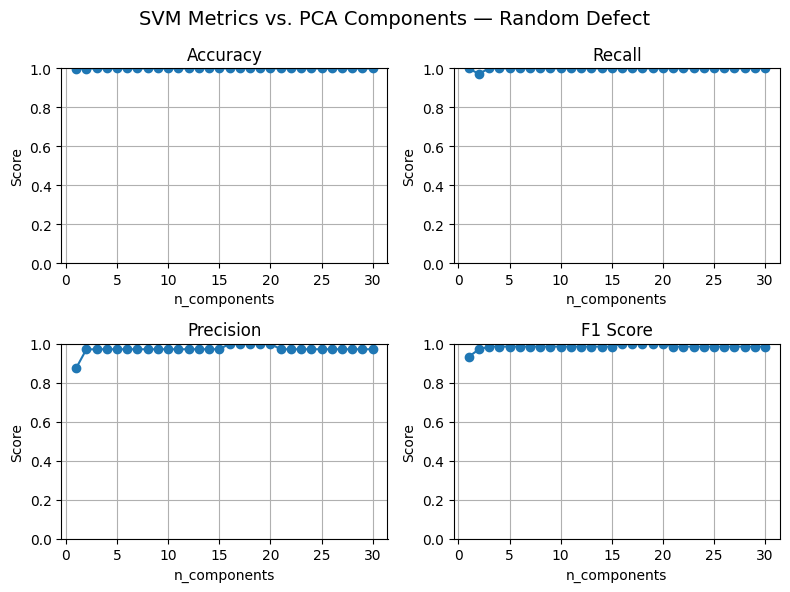

In [118]:
acc_0, recall_0, precision_0, f1_0 = end_to_end_svm(target_0, "Center")
acc_1, recall_1, precision_1, f1_1 = end_to_end_svm(target_1, "Donut")
acc_2, recall_2, precision_2, f1_2 = end_to_end_svm(target_2, "Edge-Loc")
acc_3, recall_3, precision_3, f1_3 = end_to_end_svm(target_3, "Edge-Ring")
acc_4, recall_4, precision_4, f1_4 = end_to_end_svm(target_4, "Loc")
acc_5, recall_5, precision_5, f1_5 = end_to_end_svm(target_5, "Near-Full")
acc_6, recall_6, precision_6, f1_6 = end_to_end_svm(target_6, "Scratch")
acc_7, recall_7, precision_7, f1_7 = end_to_end_svm(target_7, "Random")


In [141]:
full_dataset_SVC_results_dict = {
    "Center": (acc_0, recall_0, precision_0, f1_0),
    "Donut": (acc_1, recall_1, precision_1, f1_1),
    "Edge-Loc": (acc_2, recall_2, precision_2, f1_2),
    "Edge-Ring": (acc_3, recall_3, precision_3, f1_3),
    "Loc": (acc_4, recall_4, precision_4, f1_4),
    "Near-Full": (acc_5, recall_5, precision_5, f1_5),
    "Scratch": (acc_6, recall_6, precision_6, f1_6),
    "Random": (acc_7, recall_7, precision_7, f1_7)
}

with open("SVM_full_dataset_results.pkl", "wb") as f:
    pickle.dump(full_dataset_SVC_results_dict, f)

## Now running classical SVC on the limited dataset
* Training size = 6,082 images
* Testing size = 1,521 images


Evaluating SVM for Center defect with varying PCA components...

1 PCA components:
Total variance explained: 0.058
Confusion Matrix:
 [[329 672]
 [ 53 467]]


2 PCA components:
Total variance explained: 0.097
Confusion Matrix:
 [[366 635]
 [ 29 491]]


3 PCA components:
Total variance explained: 0.124
Confusion Matrix:
 [[773 228]
 [ 94 426]]


4 PCA components:
Total variance explained: 0.142
Confusion Matrix:
 [[908  93]
 [ 33 487]]


5 PCA components:
Total variance explained: 0.153
Confusion Matrix:
 [[909  92]
 [ 31 489]]


6 PCA components:
Total variance explained: 0.164
Confusion Matrix:
 [[914  87]
 [ 31 489]]


7 PCA components:
Total variance explained: 0.174
Confusion Matrix:
 [[915  86]
 [ 28 492]]


8 PCA components:
Total variance explained: 0.184
Confusion Matrix:
 [[917  84]
 [ 31 489]]


9 PCA components:
Total variance explained: 0.191
Confusion Matrix:
 [[926  75]
 [ 30 490]]


10 PCA components:
Total variance explained: 0.199
Confusion Matrix:
 [[935  66]
 [ 33 4

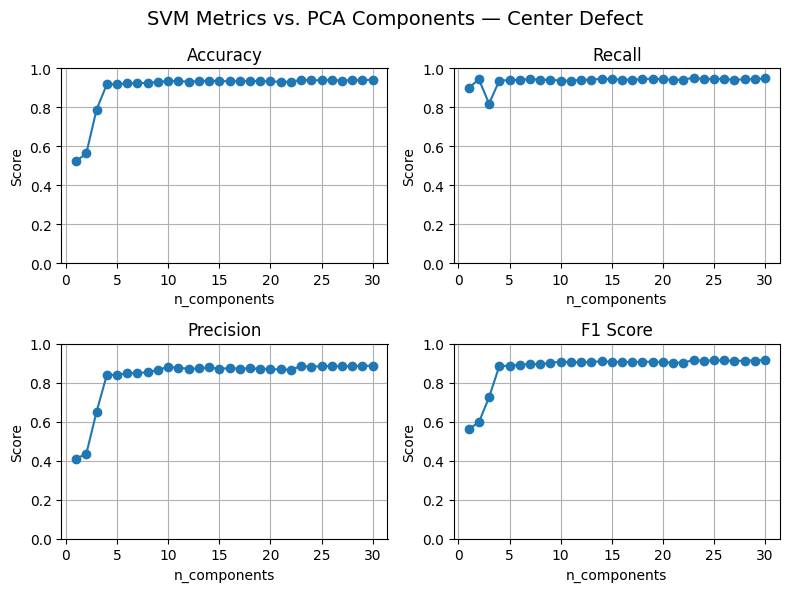


Evaluating SVM for Donut defect with varying PCA components...

1 PCA components:
Total variance explained: 0.057
Confusion Matrix:
 [[874 167]
 [ 87 393]]


2 PCA components:
Total variance explained: 0.096
Confusion Matrix:
 [[899 142]
 [ 90 390]]


3 PCA components:
Total variance explained: 0.123
Confusion Matrix:
 [[882 159]
 [ 24 456]]


4 PCA components:
Total variance explained: 0.141
Confusion Matrix:
 [[996  45]
 [ 28 452]]


5 PCA components:
Total variance explained: 0.153
Confusion Matrix:
 [[1002   39]
 [  32  448]]


6 PCA components:
Total variance explained: 0.164
Confusion Matrix:
 [[999  42]
 [ 32 448]]


7 PCA components:
Total variance explained: 0.173
Confusion Matrix:
 [[1003   38]
 [  28  452]]


8 PCA components:
Total variance explained: 0.180
Confusion Matrix:
 [[1010   31]
 [  26  454]]


9 PCA components:
Total variance explained: 0.188
Confusion Matrix:
 [[1026   15]
 [  21  459]]


10 PCA components:
Total variance explained: 0.195
Confusion Matrix:
 [[1

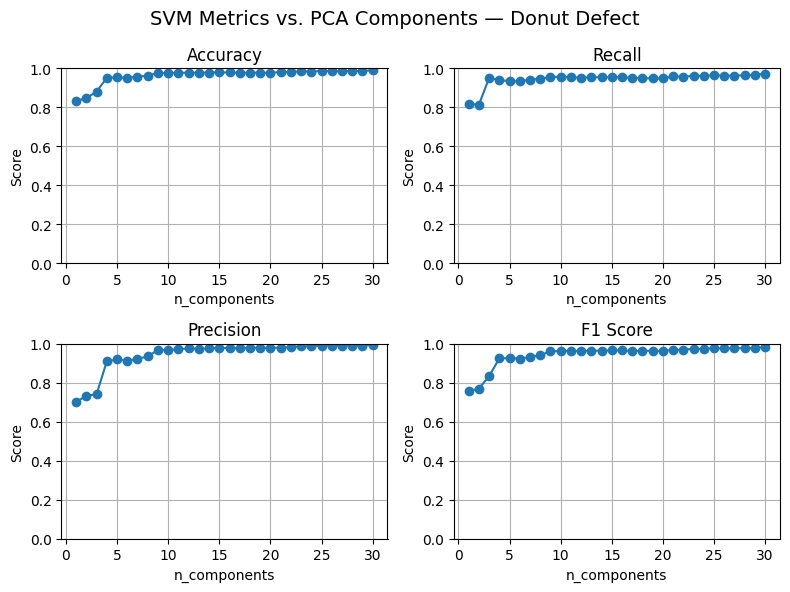


Evaluating SVM for Edge-Loc defect with varying PCA components...

1 PCA components:
Total variance explained: 0.054
Confusion Matrix:
 [[225 776]
 [ 70 450]]


2 PCA components:
Total variance explained: 0.093
Confusion Matrix:
 [[948  53]
 [ 44 476]]


3 PCA components:
Total variance explained: 0.120
Confusion Matrix:
 [[938  63]
 [ 38 482]]


4 PCA components:
Total variance explained: 0.137
Confusion Matrix:
 [[934  67]
 [ 39 481]]


5 PCA components:
Total variance explained: 0.149
Confusion Matrix:
 [[930  71]
 [ 39 481]]


6 PCA components:
Total variance explained: 0.160
Confusion Matrix:
 [[930  71]
 [ 40 480]]


7 PCA components:
Total variance explained: 0.171
Confusion Matrix:
 [[930  71]
 [ 39 481]]


8 PCA components:
Total variance explained: 0.180
Confusion Matrix:
 [[927  74]
 [ 39 481]]


9 PCA components:
Total variance explained: 0.188
Confusion Matrix:
 [[931  70]
 [ 37 483]]


10 PCA components:
Total variance explained: 0.195
Confusion Matrix:
 [[932  69]
 [ 38

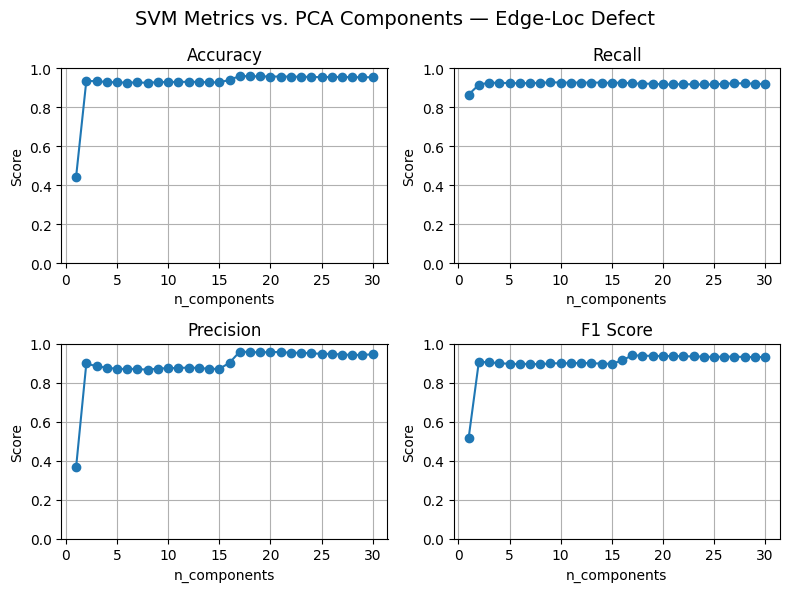


Evaluating SVM for Edge-Ring defect with varying PCA components...

1 PCA components:
Total variance explained: 0.057
Confusion Matrix:
 [[492 549]
 [ 91 389]]


2 PCA components:
Total variance explained: 0.096
Confusion Matrix:
 [[964  77]
 [  2 478]]


3 PCA components:
Total variance explained: 0.124
Confusion Matrix:
 [[962  79]
 [  1 479]]


4 PCA components:
Total variance explained: 0.142
Confusion Matrix:
 [[965  76]
 [  1 479]]


5 PCA components:
Total variance explained: 0.153
Confusion Matrix:
 [[963  78]
 [  1 479]]


6 PCA components:
Total variance explained: 0.164
Confusion Matrix:
 [[964  77]
 [  2 478]]


7 PCA components:
Total variance explained: 0.174
Confusion Matrix:
 [[964  77]
 [  2 478]]


8 PCA components:
Total variance explained: 0.181
Confusion Matrix:
 [[965  76]
 [  1 479]]


9 PCA components:
Total variance explained: 0.188
Confusion Matrix:
 [[966  75]
 [  2 478]]


10 PCA components:
Total variance explained: 0.195
Confusion Matrix:
 [[965  76]
 [  

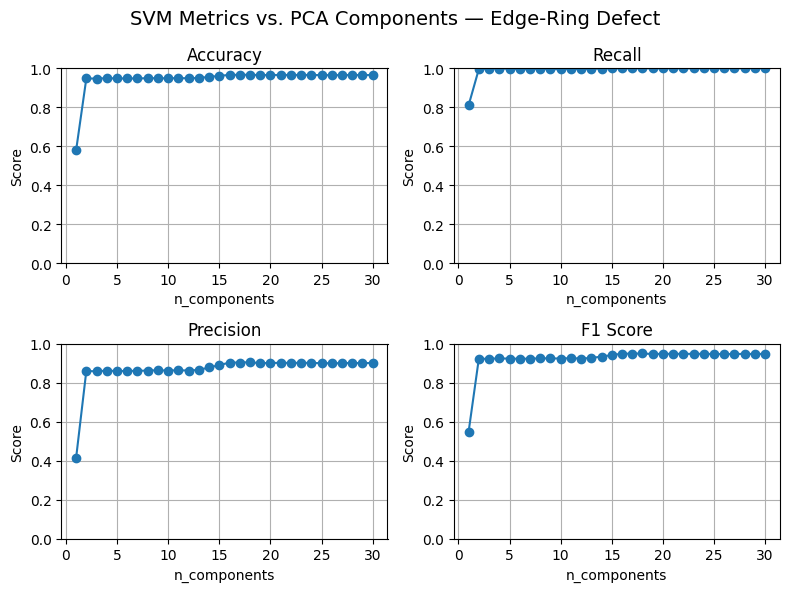


Evaluating SVM for Loc defect with varying PCA components...

1 PCA components:
Total variance explained: 0.057
Confusion Matrix:
 [[450 351]
 [125 595]]


2 PCA components:
Total variance explained: 0.097
Confusion Matrix:
 [[459 342]
 [125 595]]


3 PCA components:
Total variance explained: 0.124
Confusion Matrix:
 [[712  89]
 [133 587]]


4 PCA components:
Total variance explained: 0.142
Confusion Matrix:
 [[728  73]
 [144 576]]


5 PCA components:
Total variance explained: 0.153
Confusion Matrix:
 [[731  70]
 [149 571]]


6 PCA components:
Total variance explained: 0.164
Confusion Matrix:
 [[727  74]
 [148 572]]


7 PCA components:
Total variance explained: 0.173
Confusion Matrix:
 [[750  51]
 [140 580]]


8 PCA components:
Total variance explained: 0.181
Confusion Matrix:
 [[770  31]
 [136 584]]


9 PCA components:
Total variance explained: 0.189
Confusion Matrix:
 [[781  20]
 [120 600]]


10 PCA components:
Total variance explained: 0.195
Confusion Matrix:
 [[788  13]
 [116 604]

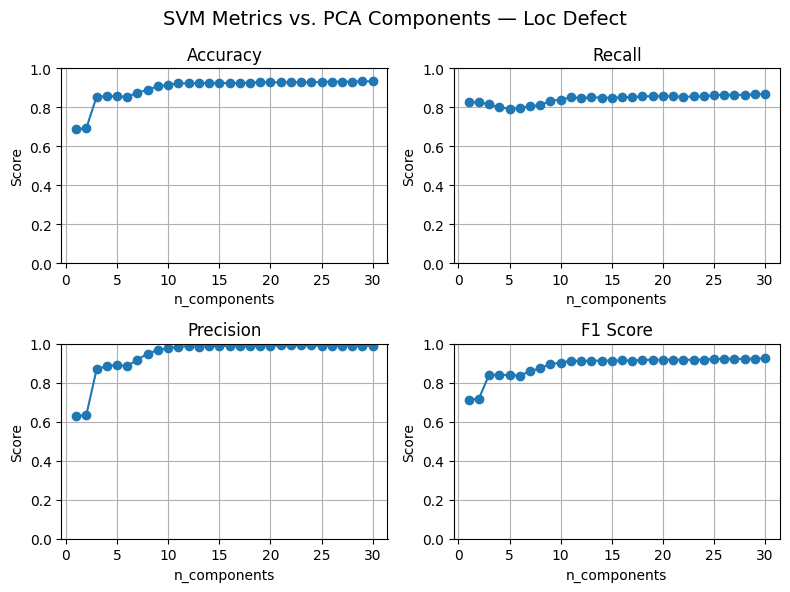


Evaluating SVM for Near-Full defect with varying PCA components...

1 PCA components:
Total variance explained: 0.055
Confusion Matrix:
 [[1500   15]
 [   0    6]]


2 PCA components:
Total variance explained: 0.094
Confusion Matrix:
 [[1507    8]
 [   0    6]]


3 PCA components:
Total variance explained: 0.122
Confusion Matrix:
 [[1515    0]
 [   0    6]]


4 PCA components:
Total variance explained: 0.140
Confusion Matrix:
 [[1515    0]
 [   0    6]]


5 PCA components:
Total variance explained: 0.151
Confusion Matrix:
 [[1515    0]
 [   0    6]]


6 PCA components:
Total variance explained: 0.162
Confusion Matrix:
 [[1515    0]
 [   0    6]]


7 PCA components:
Total variance explained: 0.171
Confusion Matrix:
 [[1515    0]
 [   0    6]]


8 PCA components:
Total variance explained: 0.179
Confusion Matrix:
 [[1515    0]
 [   0    6]]


9 PCA components:
Total variance explained: 0.187
Confusion Matrix:
 [[1515    0]
 [   0    6]]


10 PCA components:
Total variance explained: 0.19

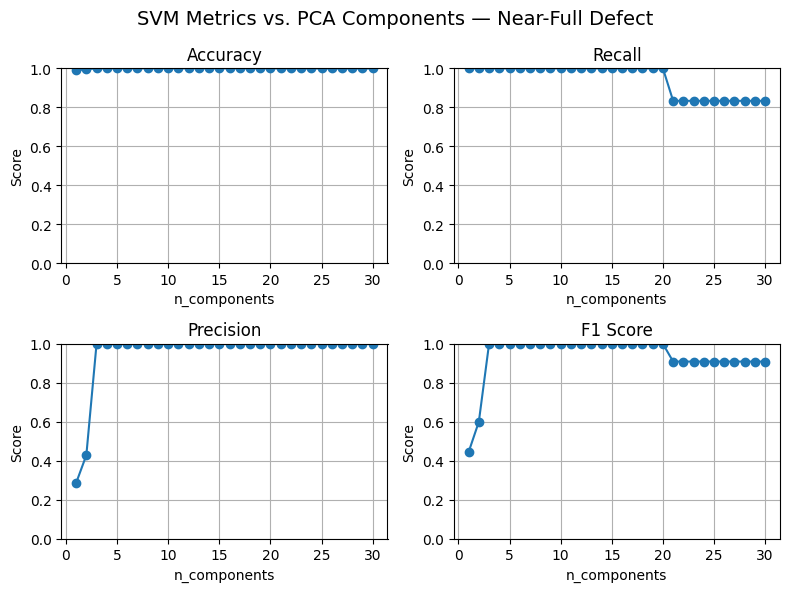


Evaluating SVM for Scratch defect with varying PCA components...

1 PCA components:
Total variance explained: 0.058
Confusion Matrix:
 [[231 530]
 [119 641]]


2 PCA components:
Total variance explained: 0.097
Confusion Matrix:
 [[218 543]
 [ 92 668]]


3 PCA components:
Total variance explained: 0.125
Confusion Matrix:
 [[452 309]
 [242 518]]


4 PCA components:
Total variance explained: 0.143
Confusion Matrix:
 [[459 302]
 [247 513]]


5 PCA components:
Total variance explained: 0.155
Confusion Matrix:
 [[479 282]
 [219 541]]


6 PCA components:
Total variance explained: 0.166
Confusion Matrix:
 [[485 276]
 [125 635]]


7 PCA components:
Total variance explained: 0.175
Confusion Matrix:
 [[476 285]
 [113 647]]


8 PCA components:
Total variance explained: 0.183
Confusion Matrix:
 [[509 252]
 [ 98 662]]


9 PCA components:
Total variance explained: 0.190
Confusion Matrix:
 [[533 228]
 [ 68 692]]


10 PCA components:
Total variance explained: 0.197
Confusion Matrix:
 [[541 220]
 [ 71 

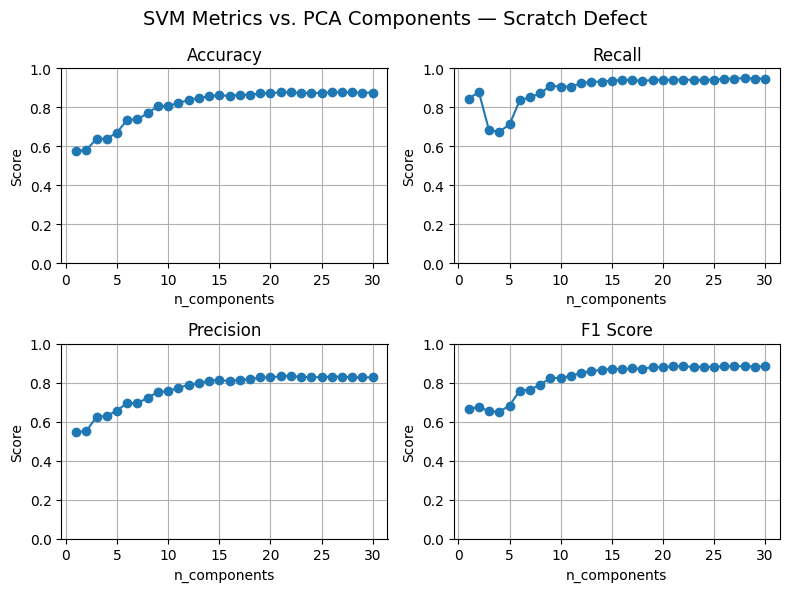


Evaluating SVM for Random defect with varying PCA components...

1 PCA components:
Total variance explained: 0.056
Confusion Matrix:
 [[1481    5]
 [   0   35]]


2 PCA components:
Total variance explained: 0.095
Confusion Matrix:
 [[1485    1]
 [   1   34]]


3 PCA components:
Total variance explained: 0.123
Confusion Matrix:
 [[1485    1]
 [   0   35]]


4 PCA components:
Total variance explained: 0.141
Confusion Matrix:
 [[1485    1]
 [   0   35]]


5 PCA components:
Total variance explained: 0.152
Confusion Matrix:
 [[1485    1]
 [   0   35]]


6 PCA components:
Total variance explained: 0.163
Confusion Matrix:
 [[1485    1]
 [   0   35]]


7 PCA components:
Total variance explained: 0.173
Confusion Matrix:
 [[1485    1]
 [   0   35]]


8 PCA components:
Total variance explained: 0.181
Confusion Matrix:
 [[1485    1]
 [   0   35]]


9 PCA components:
Total variance explained: 0.188
Confusion Matrix:
 [[1485    1]
 [   0   35]]


10 PCA components:
Total variance explained: 0.195
C

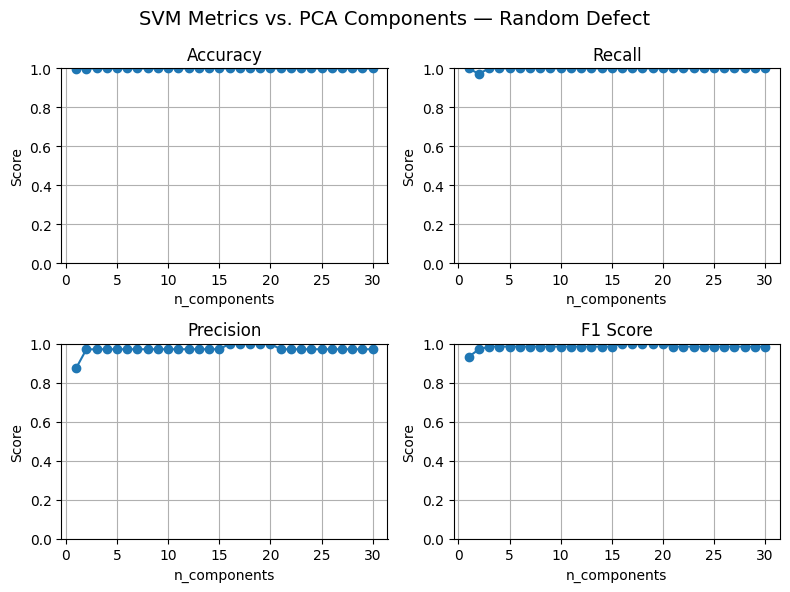

In [142]:
acc_0_lim, recall_0_lim, precision_0_lim, f1_0_lim = end_to_end_svm(target_0, "Center")
acc_1_lim, recall_1_lim, precision_1_lim, f1_1_lim = end_to_end_svm(target_1, "Donut")
acc_2_lim, recall_2_lim, precision_2_lim, f1_2_lim = end_to_end_svm(target_2, "Edge-Loc")
acc_3_lim, recall_3_lim, precision_3_lim, f1_3_lim = end_to_end_svm(target_3, "Edge-Ring")
acc_4_lim, recall_4_lim, precision_4_lim, f1_4_lim = end_to_end_svm(target_4, "Loc")
acc_5_lim, recall_5_lim, precision_5_lim, f1_5_lim = end_to_end_svm(target_5, "Near-Full")
acc_6_lim, recall_6_lim, precision_6_lim, f1_6_lim = end_to_end_svm(target_6, "Scratch")
acc_7_lim, recall_7_lim, precision_7_lim, f1_7_lim = end_to_end_svm(target_7, "Random")


In [143]:
limited_dataset_SVC_results_dict = {
    "Center": (acc_0_lim, recall_0_lim, precision_0_lim, f1_0_lim),
    "Donut": (acc_1_lim, recall_1_lim, precision_1_lim, f1_1_lim),
    "Edge-Loc": (acc_2_lim, recall_2_lim, precision_2_lim, f1_2_lim),
    "Edge-Ring": (acc_3_lim, recall_3_lim, precision_3_lim, f1_3_lim),
    "Loc": (acc_4_lim, recall_4_lim, precision_4_lim, f1_4_lim),
    "Near-Full": (acc_5_lim, recall_5_lim, precision_5_lim, f1_5_lim),
    "Scratch": (acc_6_lim, recall_6_lim, precision_6_lim, f1_6_lim),
    "Random": (acc_7_lim, recall_7_lim, precision_7_lim, f1_7_lim)
}

with open("SVM_limited_dataset_results.pkl", "wb") as f:
    pickle.dump(limited_dataset_SVC_results_dict, f)

## QSVC

In [120]:
def quantum_svm(y, n):
    X_train1, X_test1, y_train1, y_test1 = train_test_split(X_flat, y, test_size=0.2, random_state=42, stratify=y)
    X_train, X_test, y_train, y_test = train_test_split(X_test1, y_test1, test_size=0.2, random_state=42, stratify=y_test1)

    # Scale
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # PCA
    pca = PCA(n_components=n)
    X_train = pca.fit_transform(X_train)
    X_test = pca.transform(X_test)

    # Feature map: n qubits to match PCA output dimension
    feature_map = zz_feature_map(feature_dimension=n, reps=2)

    # Quantum kernel
    kernel = FidelityStatevectorKernel(feature_map=feature_map)

    # QSVC
    qsvc = QSVC(quantum_kernel=kernel, class_weight='balanced')
    qsvc.fit(X_train, y_train)
    y_pred = qsvc.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

    return acc, rec, prec, f1

In [124]:
def end_to_end_quantum_svm(target_defect, defect_label):
    print(f"\nEvaluating QSVM for {defect_label} defect with varying PCA components...\n")
    accuracy_list = []
    recall_list = []
    precision_list = []
    f1_list = []

    endpoint=11
    for i in range(2,endpoint+1):
        print(f"{i} PCA components:")
        acc, recall, precision, f1 = quantum_svm(target_defect,i)
        accuracy_list.append(acc)
        recall_list.append(recall)
        precision_list.append(precision)
        f1_list.append(f1)
        print("\n" + "="*50 + "\n")


    n_values = range(2, endpoint+1)
    fig, axes = plt.subplots(2, 2, figsize=(8, 6))
    fig.suptitle(f"SVM Metrics vs. PCA Components — {defect_label} Defect", fontsize=14)

    for ax, (metric_name, values) in zip(axes.flatten(), zip(
        ["Accuracy", "Recall", "Precision", "F1 Score"],
        [accuracy_list, recall_list, precision_list, f1_list]
    )):
        ax.plot(n_values, values, marker='o')
        ax.set_title(metric_name)
        ax.set_xlabel("n_components")
        ax.set_ylabel("Score")
        ax.set_ylim(0, 1)
        ax.grid(True)

    plt.tight_layout()
    plt.savefig(f'SVM_results/quantum_svm_{defect_label}_defect.png', dpi=300)
    plt.show()
    

    return accuracy_list, recall_list, precision_list, f1_list


Evaluating QSVM for Center defect with varying PCA components...

2 PCA components:
Confusion Matrix:
[[412 589]
 [226 294]]


3 PCA components:
Confusion Matrix:
[[454 547]
 [238 282]]


4 PCA components:
Confusion Matrix:
[[510 491]
 [278 242]]


5 PCA components:
Confusion Matrix:
[[522 479]
 [282 238]]


6 PCA components:
Confusion Matrix:
[[558 443]
 [272 248]]


7 PCA components:
Confusion Matrix:
[[673 328]
 [324 196]]


8 PCA components:
Confusion Matrix:
[[840 161]
 [393 127]]


9 PCA components:
Confusion Matrix:
[[984  17]
 [492  28]]


10 PCA components:
Confusion Matrix:
[[1001    0]
 [ 503   17]]


11 PCA components:
Confusion Matrix:
[[1001    0]
 [ 503   17]]




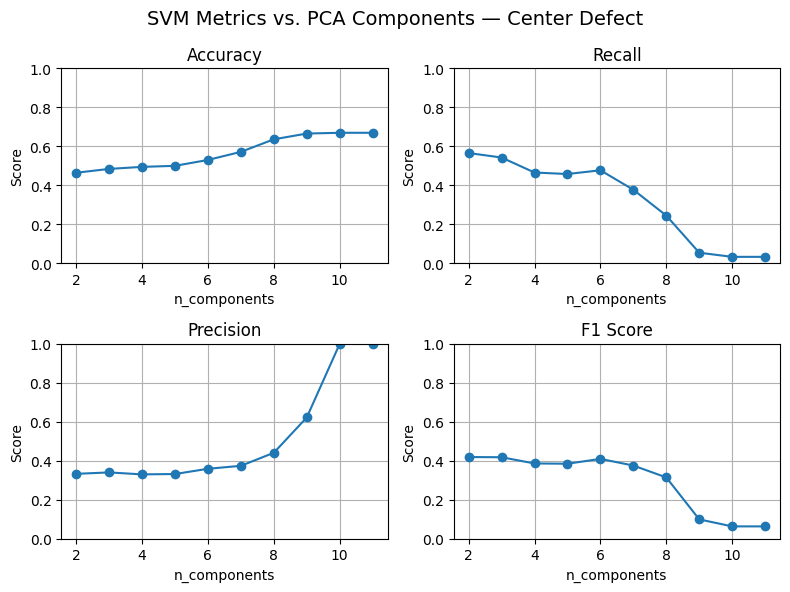


Evaluating QSVM for Donut defect with varying PCA components...

2 PCA components:
Confusion Matrix:
[[470 571]
 [207 273]]


3 PCA components:
Confusion Matrix:
[[577 464]
 [258 222]]


4 PCA components:
Confusion Matrix:
[[568 473]
 [248 232]]


5 PCA components:
Confusion Matrix:
[[555 486]
 [251 229]]


6 PCA components:
Confusion Matrix:
[[606 435]
 [271 209]]


7 PCA components:
Confusion Matrix:
[[702 339]
 [327 153]]


8 PCA components:
Confusion Matrix:
[[918 123]
 [414  66]]


9 PCA components:
Confusion Matrix:
[[1031   10]
 [ 475    5]]


10 PCA components:
Confusion Matrix:
[[1041    0]
 [ 480    0]]


11 PCA components:
Confusion Matrix:
[[1041    0]
 [ 480    0]]




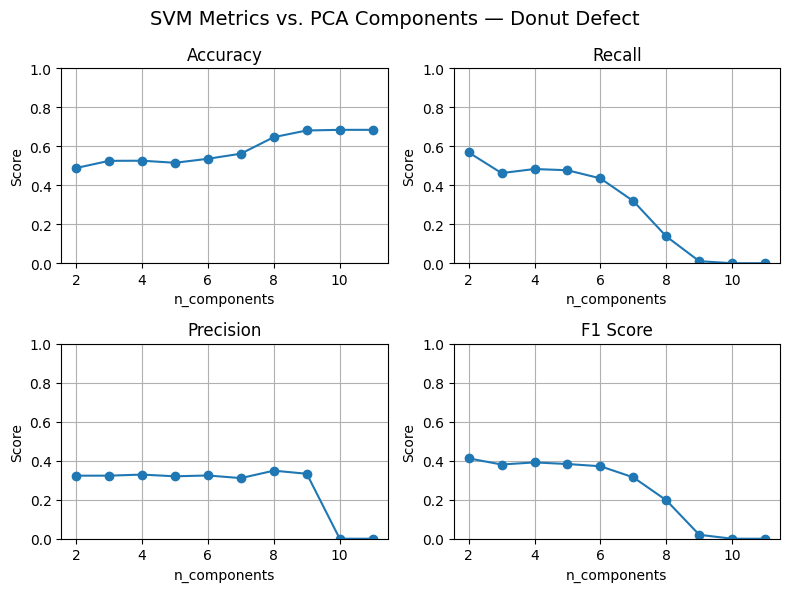


Evaluating QSVM for Edge-Loc defect with varying PCA components...

2 PCA components:
Confusion Matrix:
[[368 633]
 [197 323]]


3 PCA components:
Confusion Matrix:
[[505 496]
 [280 240]]


4 PCA components:
Confusion Matrix:
[[497 504]
 [249 271]]


5 PCA components:
Confusion Matrix:
[[546 455]
 [279 241]]


6 PCA components:
Confusion Matrix:
[[574 427]
 [267 253]]


7 PCA components:
Confusion Matrix:
[[677 324]
 [336 184]]


8 PCA components:
Confusion Matrix:
[[848 153]
 [414 106]]


9 PCA components:
Confusion Matrix:
[[986  15]
 [494  26]]


10 PCA components:
Confusion Matrix:
[[1001    0]
 [ 503   17]]


11 PCA components:
Confusion Matrix:
[[1001    0]
 [ 503   17]]




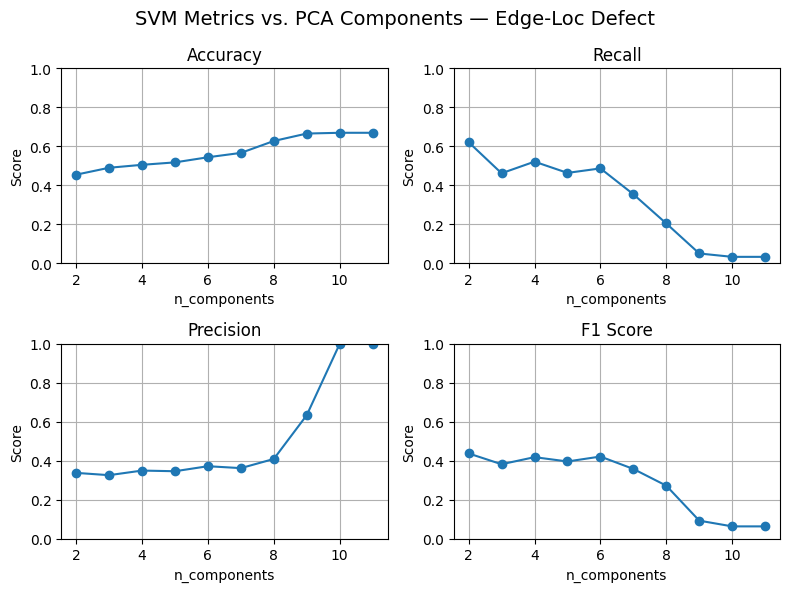


Evaluating QSVM for Edge-Ring defect with varying PCA components...

2 PCA components:
Confusion Matrix:
[[349 692]
 [137 343]]


3 PCA components:
Confusion Matrix:
[[589 452]
 [260 220]]


4 PCA components:
Confusion Matrix:
[[546 495]
 [263 217]]


5 PCA components:
Confusion Matrix:
[[571 470]
 [254 226]]


6 PCA components:
Confusion Matrix:
[[626 415]
 [288 192]]


7 PCA components:
Confusion Matrix:
[[721 320]
 [330 150]]


8 PCA components:
Confusion Matrix:
[[909 132]
 [414  66]]


9 PCA components:
Confusion Matrix:
[[1033    8]
 [ 479    1]]


10 PCA components:
Confusion Matrix:
[[1041    0]
 [ 480    0]]


11 PCA components:
Confusion Matrix:
[[1041    0]
 [ 480    0]]




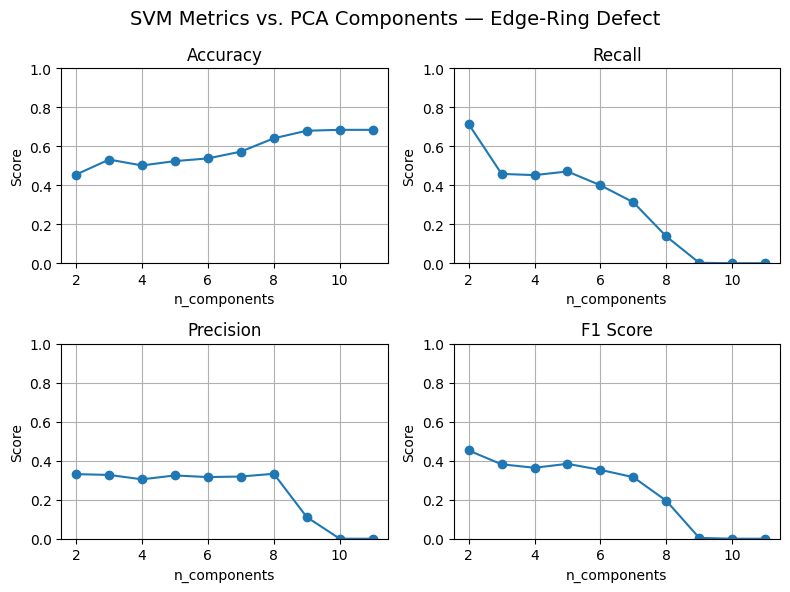


Evaluating QSVM for Loc defect with varying PCA components...

2 PCA components:
Confusion Matrix:
[[524 277]
 [451 269]]


3 PCA components:
Confusion Matrix:
[[396 405]
 [370 350]]


4 PCA components:
Confusion Matrix:
[[411 390]
 [371 349]]


5 PCA components:
Confusion Matrix:
[[417 384]
 [388 332]]


6 PCA components:
Confusion Matrix:
[[419 382]
 [354 366]]


7 PCA components:
Confusion Matrix:
[[386 415]
 [355 365]]


8 PCA components:
Confusion Matrix:
[[460 341]
 [381 339]]


9 PCA components:
Confusion Matrix:
[[510 291]
 [430 290]]


10 PCA components:
Confusion Matrix:
[[574 227]
 [515 205]]


11 PCA components:
Confusion Matrix:
[[718  83]
 [613 107]]




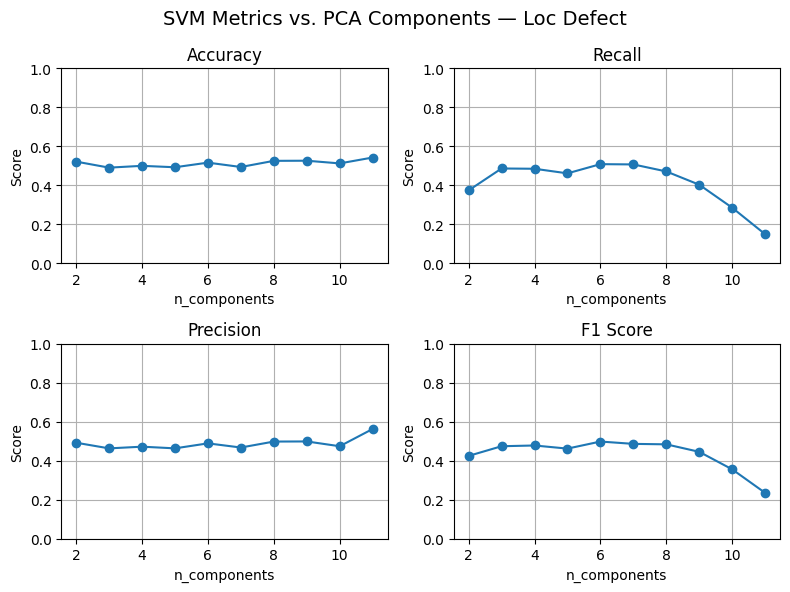


Evaluating QSVM for Near-Full defect with varying PCA components...

2 PCA components:
Confusion Matrix:
[[824 691]
 [  5   1]]


3 PCA components:
Confusion Matrix:
[[1336  179]
 [   6    0]]


4 PCA components:
Confusion Matrix:
[[1485   30]
 [   6    0]]


5 PCA components:
Confusion Matrix:
[[1515    0]
 [   6    0]]


6 PCA components:
Confusion Matrix:
[[1515    0]
 [   6    0]]


7 PCA components:
Confusion Matrix:
[[1515    0]
 [   6    0]]


8 PCA components:
Confusion Matrix:
[[1515    0]
 [   6    0]]


9 PCA components:
Confusion Matrix:
[[1515    0]
 [   6    0]]


10 PCA components:
Confusion Matrix:
[[1515    0]
 [   6    0]]


11 PCA components:
Confusion Matrix:
[[1515    0]
 [   6    0]]




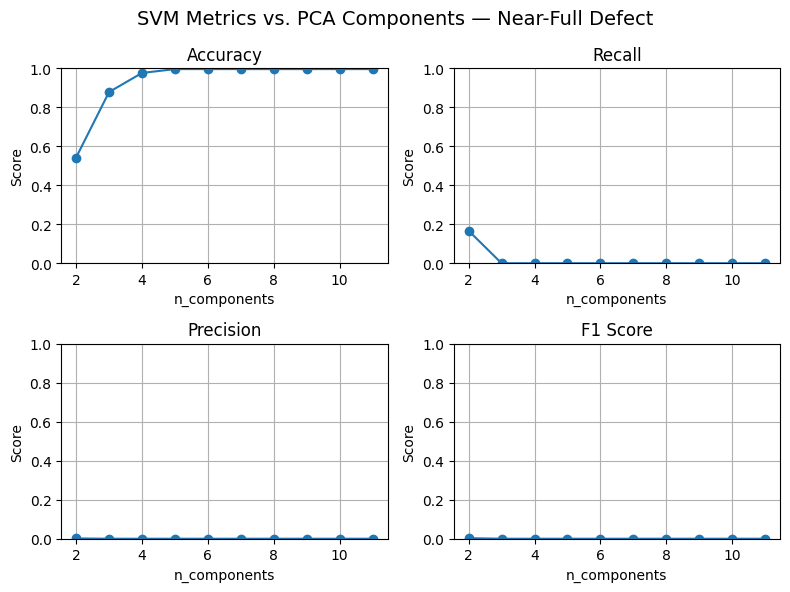


Evaluating QSVM for Scratch defect with varying PCA components...

2 PCA components:
Confusion Matrix:
[[350 411]
 [374 386]]


3 PCA components:
Confusion Matrix:
[[392 369]
 [400 360]]


4 PCA components:
Confusion Matrix:
[[379 382]
 [386 374]]


5 PCA components:
Confusion Matrix:
[[373 388]
 [400 360]]


6 PCA components:
Confusion Matrix:
[[373 388]
 [402 358]]


7 PCA components:
Confusion Matrix:
[[382 379]
 [384 376]]


8 PCA components:
Confusion Matrix:
[[384 377]
 [414 346]]


9 PCA components:
Confusion Matrix:
[[423 338]
 [403 357]]


10 PCA components:
Confusion Matrix:
[[428 333]
 [424 336]]


11 PCA components:
Confusion Matrix:
[[467 294]
 [473 287]]




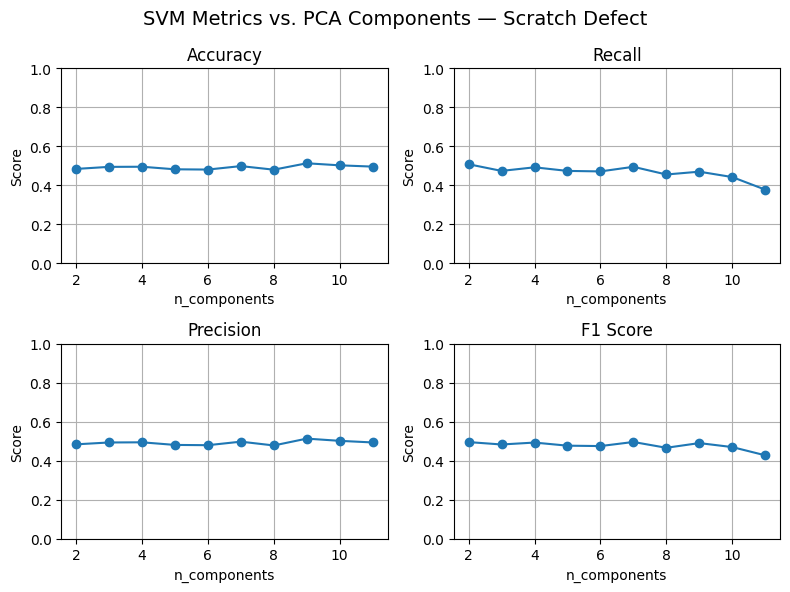


Evaluating QSVM for Random defect with varying PCA components...

2 PCA components:
Confusion Matrix:
[[732 754]
 [ 21  14]]


3 PCA components:
Confusion Matrix:
[[909 577]
 [ 23  12]]


4 PCA components:
Confusion Matrix:
[[1034  452]
 [  23   12]]


5 PCA components:
Confusion Matrix:
[[1389   97]
 [  27    8]]


6 PCA components:
Confusion Matrix:
[[1479    7]
 [  35    0]]


7 PCA components:
Confusion Matrix:
[[1486    0]
 [  35    0]]


8 PCA components:
Confusion Matrix:
[[1486    0]
 [  35    0]]


9 PCA components:
Confusion Matrix:
[[1486    0]
 [  35    0]]


10 PCA components:
Confusion Matrix:
[[1486    0]
 [  35    0]]


11 PCA components:
Confusion Matrix:
[[1486    0]
 [  35    0]]




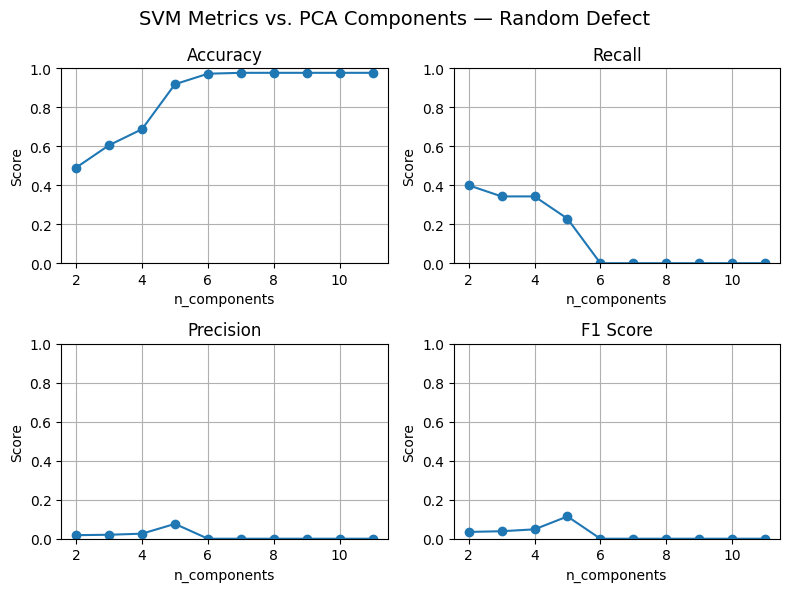

In [125]:
qc_acc_0, qc_recall_0, qc_precision_0, qc_f1_0 = end_to_end_quantum_svm(target_0, "Center")
qc_acc_1, qc_recall_1, qc_precision_1, qc_f1_1 = end_to_end_quantum_svm(target_1, "Donut")
qc_acc_2, qc_recall_2, qc_precision_2, qc_f1_2 = end_to_end_quantum_svm(target_2, "Edge-Loc")
qc_acc_3, qc_recall_3, qc_precision_3, qc_f1_3 = end_to_end_quantum_svm(target_3, "Edge-Ring")
qc_acc_4, qc_recall_4, qc_precision_4, qc_f1_4 = end_to_end_quantum_svm(target_4, "Loc")
qc_acc_5, qc_recall_5, qc_precision_5, qc_f1_5 = end_to_end_quantum_svm(target_5, "Near-Full")
qc_acc_6, qc_recall_6, qc_precision_6, qc_f1_6 = end_to_end_quantum_svm(target_6, "Scratch")
qc_acc_7, qc_recall_7, qc_precision_7, qc_f1_7 = end_to_end_quantum_svm(target_7, "Random")

In [145]:
limited_dataset_QSVC_results_dict = {
    "Center": (qc_acc_0, qc_recall_0, qc_precision_0, qc_f1_0),
    "Donut": (qc_acc_1, qc_recall_1, qc_precision_1, qc_f1_1),
    "Edge-Loc": (qc_acc_2, qc_recall_2, qc_precision_2, qc_f1_2),
    "Edge-Ring": (qc_acc_3, qc_recall_3, qc_precision_3, qc_f1_3),
    "Loc": (qc_acc_4, qc_recall_4, qc_precision_4, qc_f1_4),
    "Near-Full": (qc_acc_5, qc_recall_5, qc_precision_5, qc_f1_5),
    "Scratch": (qc_acc_6, qc_recall_6, qc_precision_6, qc_f1_6),
    "Random": (qc_acc_7, qc_recall_7, qc_precision_7, qc_f1_7)
}

with open("QSVC_limited_dataset_results.pkl", "wb") as f:
    pickle.dump(limited_dataset_QSVC_results_dict, f)

## Penny Lane Quantum Kernel SVC

In [148]:
import pennylane as qml
from pennylane import numpy as np

def quantum_kernel_pennylane(X_train, X_test, n):
    dev = qml.device("default.qubit", wires=n)

    # Feature map circuit — PennyLane equivalent of ZZFeatureMap reps=2
    def feature_map(x):
        for i in range(n):
            qml.Hadamard(wires=i)
            qml.RZ(2 * x[i], wires=i)
        for i in range(n - 1):
            qml.CNOT(wires=[i, i + 1])
            qml.RZ(2 * (np.pi - x[i]) * (np.pi - x[i + 1]), wires=i + 1)
            qml.CNOT(wires=[i, i + 1])
        # rep 2
        for i in range(n):
            qml.Hadamard(wires=i)
            qml.RZ(2 * x[i], wires=i)
        for i in range(n - 1):
            qml.CNOT(wires=[i, i + 1])
            qml.RZ(2 * (np.pi - x[i]) * (np.pi - x[i + 1]), wires=i + 1)
            qml.CNOT(wires=[i, i + 1])

    @qml.qnode(dev)
    def kernel_circuit(x1, x2):
        feature_map(x1)
        qml.adjoint(feature_map)(x2)
        return qml.probs(wires=range(n))

    def kernel_fn(x1, x2):
        # Fidelity = probability of measuring all zeros
        return kernel_circuit(x1, x2)[0]

    # Build kernel matrices
    def build_kernel_matrix(A, B):
        return np.array([[kernel_fn(a, b) for b in B] for a in A])

    K_train = build_kernel_matrix(X_train, X_train)
    K_test  = build_kernel_matrix(X_test, X_train)

    return K_train, K_test


def quantum_svm_pennylane(y, n):
    # Subsample
    X_sub, _, y_sub, _ = train_test_split(
        X_flat, y, test_size=0.2, random_state=42, stratify=y
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
    )

    # Scale
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # PCA
    pca = PCA(n_components=n)
    X_train = pca.fit_transform(X_train)
    X_test  = pca.transform(X_test)

    # Build kernel matrices
    K_train, K_test = quantum_kernel_pennylane(X_train, X_test, n)

    # Pass precomputed kernel to sklearn SVC
    svc = SVC(kernel='precomputed', class_weight='balanced')
    svc.fit(K_train, y_train)
    y_pred = svc.predict(K_test)

    acc  = accuracy_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    return acc, rec, prec, f1

# VQC Qiskit

In [162]:
from qiskit.circuit.library import zz_feature_map, real_amplitudes
from qiskit_machine_learning.algorithms import VQC
from qiskit_machine_learning.optimizers import COBYLA
from qiskit.primitives import StatevectorSampler

def vqc_classifier(y, n):
    X_train1, X_test1, y_train1, y_test1 = train_test_split(
        X_flat, y, test_size=0.2, random_state=42, stratify=y
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X_test1, y_test1, test_size=0.2, random_state=42, stratify=y_test1
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    pca = PCA(n_components=n)
    X_train = pca.fit_transform(X_train)
    X_test  = pca.transform(X_test)

    # Feature map encodes input data (same as QSVC)
    feature_map = zz_feature_map(feature_dimension=n, reps=2)

    # Ansatz: trainable circuit whose parameters are optimized
    ansatz = real_amplitudes(num_qubits=n, reps=2)

    # VQC
    vqc = VQC(
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=COBYLA(maxiter=100),
        sampler=StatevectorSampler(),
    )

    vqc.fit(X_train, y_train)
    y_pred = vqc.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

    return acc, rec, prec, f1

In [163]:
vqc_acc_0, vqc_recall_0, vqc_precision_0, vqc_f1_0 = vqc_classifier(target_0, 2)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Confusion Matrix:
[[644 357]
 [333 187]]
